# XGBoost - Modelo Aplicado a demanda energética Alemania

In [1]:
# Modelado
#import tensorflow as tf # no se requiere
#from tensorflow import keras # no se requiere
#from keras.models import Sequential # no se requiere
#from keras import Input # no se requiere
#from keras.layers import Dense, SimpleRNN # no se requiere

import xgboost

# procesamiento
import pandas as pd
import numpy as np
import holidays
import json
# ml, procesamiento
#import sklearn
from sklearn.model_selection import TimeSeriesSplit
#from sklearn.model_selection import train_test_split # no se requiere
from sklearn.preprocessing import MinMaxScaler 
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.model_selection import GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
# analisis series de tiempo
#from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # no se requiere
#from statsmodels.tsa.stattools import adfuller # no se requiere
from statsmodels.graphics.tsaplots import acf, pacf
# optimización, warnings
import optuna
import warnings
import optuna.visualization as vis
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split

# visual
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
#plt.style.use("seaborn-v0_8-darkgrid")
#sns.set_palette("viridis")

# semilla para reproductibilidad
# configuración de reproductbilidad
np.random.seed(42)
from optuna.samplers import TPESampler # reproductibilidad con optuna

c:\Users\JUAN DAVID\Desktop\maestria docs\codigo python\venv_tesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Se cargan los valores de consumo a nivel semanal. La semana en este caso se toma el primer día como lunes, es fecha muestra el promedio de la semana y se formatean las fechas en formato date. El orden de las observaciones es de $10^6$

In [2]:
date_close =  pd.read_csv("../../../data/csv/EC_GER_Weekly.csv")
df_data_close = pd.DataFrame(date_close.copy()) # copia del df de precios de cierre como df
df_data_close["Start date"] = pd.to_datetime(df_data_close["Start date"])
df_data_close = df_data_close.sort_values(by="Start date", ascending=True) # se ordena por fecha ascendente
df_data_close.head()


,Start date,value
0,2015-01-05,1.240580e+06
1,2015-01-12,1.465239e+06
2,2015-01-19,1.479857e+06
3,2015-01-26,1.516270e+06
4,2015-02-02,1.507588e+06


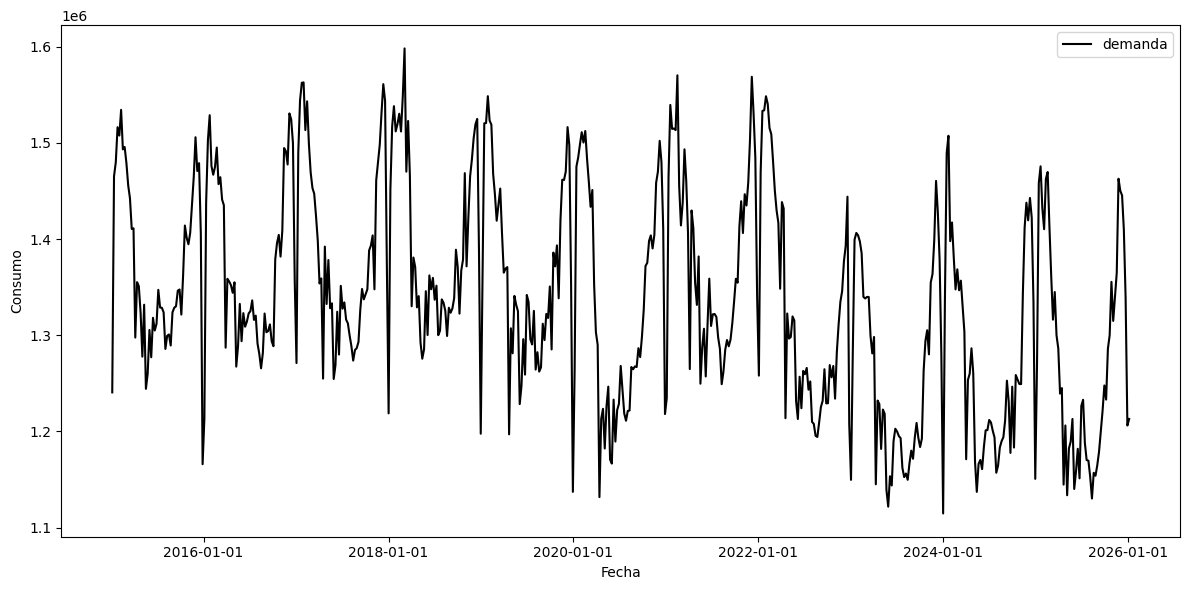

In [3]:
# se grafican los datos de consumo de forma semanal
plt.figure(figsize=(12,6))
plt.plot(df_data_close["Start date"], df_data_close["value"], label="demanda", color="black")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
#plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [4]:
# se definen variables generales a tener en cuenta en el df a partir de la fecha: temporalidades: año, mes, día, día de la semana, cuatrimestre
def get_data_times(df, columnName):
    df_copy = df.copy()
    df_copy["year"] = df_copy[columnName].apply(lambda x: x.year)
    df_copy["month"] = df_copy[columnName].apply(lambda x: x.month)
    #df_copy["day"] = df_copy[columnName].apply(lambda x: x.day)
    #df_copy["dayofweek"] = df_copy[columnName].apply(lambda x: x.dayofweek)
    df_copy["quarter"] = df_copy[columnName].apply(lambda x: x.quarter)
    return df_copy

df_data_close = get_data_times(df_data_close, columnName="Start date")
df_data_close.head()

,Start date,value,year,month,quarter
0,2015-01-05,1.240580e+06,2015,1,1
1,2015-01-12,1.465239e+06,2015,1,1
2,2015-01-19,1.479857e+06,2015,1,1
3,2015-01-26,1.516270e+06,2015,1,1
4,2015-02-02,1.507588e+06,2015,2,1


In [5]:
# se añaden otras variables como el lag anterior y media móvil en distintos periodos desde el tiempo t-1,
# por eso se toma el valor rezagado de la serie
# función que recibe como argumentos un array con los nombres de las columnas y un array con los rezagos a calcular

def make_df_full_lags(df, lags, variables):
    df_copy = df.copy()
    for variable in variables:
        for lag in lags:
            df_copy[f"{variable}_lag_{str(lag)}"] = df_copy[f"{variable}"].shift(lag)

    return df_copy

variables = [col for col in df_data_close.columns if ("value" in col ) ]
# rezagos por días
# lags = [1,2,7,15,30,60,90]

# rezagos por semanas
lags = [1, 2, 3, 4, 8, 12, 52]
df_data_close = make_df_full_lags(df_data_close, lags, variables).dropna()
df_data_close = df_data_close.reset_index(drop=True)
df_data_close.head()
#df_data_close[["value", "value_lag_1", "value_lag_2"]]

,Start date,value,year,month,quarter,value_lag_1,value_lag_2,value_lag_3,value_lag_4,value_lag_8,value_lag_12,value_lag_52
0,2016-01-04,1.213233e+06,2016,1,1,1.165943e+06,1.404996e+06,1.478872e+06,1.470758e+06,1.406408e+06,1.362325e+06,1.240580e+06
1,2016-01-11,1.437911e+06,2016,1,1,1.213233e+06,1.165943e+06,1.404996e+06,1.478872e+06,1.435765e+06,1.414048e+06,1.465239e+06
2,2016-01-18,1.502718e+06,2016,1,1,1.437911e+06,1.213233e+06,1.165943e+06,1.404996e+06,1.464466e+06,1.401533e+06,1.479857e+06
3,2016-01-25,1.528752e+06,2016,1,1,1.502718e+06,1.437911e+06,1.213233e+06,1.165943e+06,1.505831e+06,1.394589e+06,1.516270e+06
4,2016-02-01,1.475937e+06,2016,2,1,1.528752e+06,1.502718e+06,1.437911e+06,1.213233e+06,1.470758e+06,1.406408e+06,1.507588e+06


In [6]:

#df_data_close["value_lag_1y"] = df_data_close["value"].shift(52)
# 52 valores atras (el valor de la semana que se quiere ver un año atras)
#df_data_close


Cálculo de medias móviles para diversos periodos, que funcionan como variables de entrada adicionales

In [7]:
# medias móviles de los precios de cierre: se crea una función para que tome las medias móviles de 
# 7,15,30,60,90 días. Se toman estas medias moviles para los precios anteriores
def make_df_full_averages(df, vars_list, ma_periods, dropna=True, overwrite=False):
    df_copy = df.copy()

    # solo permitir variables originales (sin _lag_ ni _ma_)
    clean_vars = [
        v for v in vars_list
        if v in df_copy.columns and "_lag_" not in v and "_ma_" not in v
    ]

    missing = [v for v in vars_list if v not in df_copy.columns]
    if missing:
        raise ValueError(f"Estas columnas no existen: {missing}")

    for variable in clean_vars:
        for period in ma_periods:
            name = f"{variable}_ma_{period}"

            if (name in df_copy.columns) and (not overwrite):
                continue

            df_copy[name] = (
                df_copy[variable]
                .shift(1)  # evita leakage, dado que se toma desde la posición t-1 hacia atras
                .rolling(window=period)
                .mean()
            )

    if dropna:
        df_copy = df_copy.dropna().reset_index(drop=True)

    return df_copy

# periodos para ma por días
# ma_periods = [7, 15, 30, 60, 90]

# periodos ma por semanas
ma_periods = [
    2, # dos semanas desde la anterior
    3, # tres semanas desde la anterior
    4, # 4 semanas desde la anterior (desde la ultima semana, un mes)
    8, # 8 semanas desde la anterior (desde la ultima semana, dos meses)
    12, # 12 semanas desde la anterior (desde la ultima semana, tres meses)
    16 # 16 semanas desde la anterior (desde la última semana, 4 meses)
]

df_data_close = make_df_full_averages(
    df_data_close,
    vars_list=variables,
    ma_periods=ma_periods
)

df_data_close.head()

,Start date,value,year,month,quarter,value_lag_1,value_lag_2,value_lag_3,value_lag_4,value_lag_8,value_lag_12,value_lag_52,value_ma_2,value_ma_3,value_ma_4,value_ma_8,value_ma_12,value_ma_16
0,2016-04-25,1.344112e+06,2016,4,2,1.352060e+06,1.355867e+06,1.358682e+06,1.287062e+06,1.457129e+06,1.475937e+06,1.323606e+06,1.353963e+06,1.355536e+06,1.338418e+06,1.393927e+06,1.422028e+06,1.421685e+06
1,2016-05-02,1.354987e+06,2016,5,2,1.344112e+06,1.352060e+06,1.355867e+06,1.358682e+06,1.464299e+06,1.466870e+06,1.277736e+06,1.348086e+06,1.350679e+06,1.352680e+06,1.379800e+06,1.411043e+06,1.429865e+06
2,2016-05-09,1.267394e+06,2016,5,2,1.354987e+06,1.344112e+06,1.352060e+06,1.355867e+06,1.441140e+06,1.475012e+06,1.331730e+06,1.349550e+06,1.350386e+06,1.351756e+06,1.366136e+06,1.401719e+06,1.424682e+06
3,2016-05-16,1.288666e+06,2016,5,2,1.267394e+06,1.354987e+06,1.344112e+06,1.352060e+06,1.435180e+06,1.495105e+06,1.244288e+06,1.311191e+06,1.322164e+06,1.329638e+06,1.344418e+06,1.384418e+06,1.409974e+06
4,2016-05-23,1.332559e+06,2016,5,2,1.288666e+06,1.267394e+06,1.354987e+06,1.344112e+06,1.287062e+06,1.457129e+06,1.259924e+06,1.278030e+06,1.303682e+06,1.313790e+06,1.326104e+06,1.367215e+06,1.394969e+06


Se seleccionan las variables que serán las variables de entrada del modelo

In [8]:
# selecicon de variables
target = ["value"]
features = [col for col in df_data_close.columns if (col not in target)]
features

['Start date',
 'year',
 'month',
 'quarter',
 'value_lag_1',
 'value_lag_2',
 'value_lag_3',
 'value_lag_4',
 'value_lag_8',
 'value_lag_12',
 'value_lag_52',
 'value_ma_2',
 'value_ma_3',
 'value_ma_4',
 'value_ma_8',
 'value_ma_12',
 'value_ma_16']

Se esquematizan los datos como un problema de aprendizaje supervisado: X es el array de features, y es el array de valores (columna value, que es la que se quiere predecir)

In [9]:
X = df_data_close[features].copy()
X = X.set_index("Start date")
y = df_data_close[target]

# se realiza separación train/test, el train se usa para determinar el mejor modelo en función de una métrica de error
# X_folds: conjunto de datos para entrenar el modelo por folds
# y_folds: conjunto de validacion de train

# X_val: conjunto de val de features
#y val: conjunto de val de valores
percentage = 0.9
folds_data_size = int(len(df_data_close) * percentage)
#folds_data = df_data_close[:folds_data_size]
#val_data = df_data_close[folds_data_size:]
X_folds = X.iloc[:folds_data_size]
y_folds = y.iloc[:folds_data_size]

X_val = X.iloc[folds_data_size:]
y_val = y.iloc[folds_data_size:]

Se grafican los datos Folds/Val

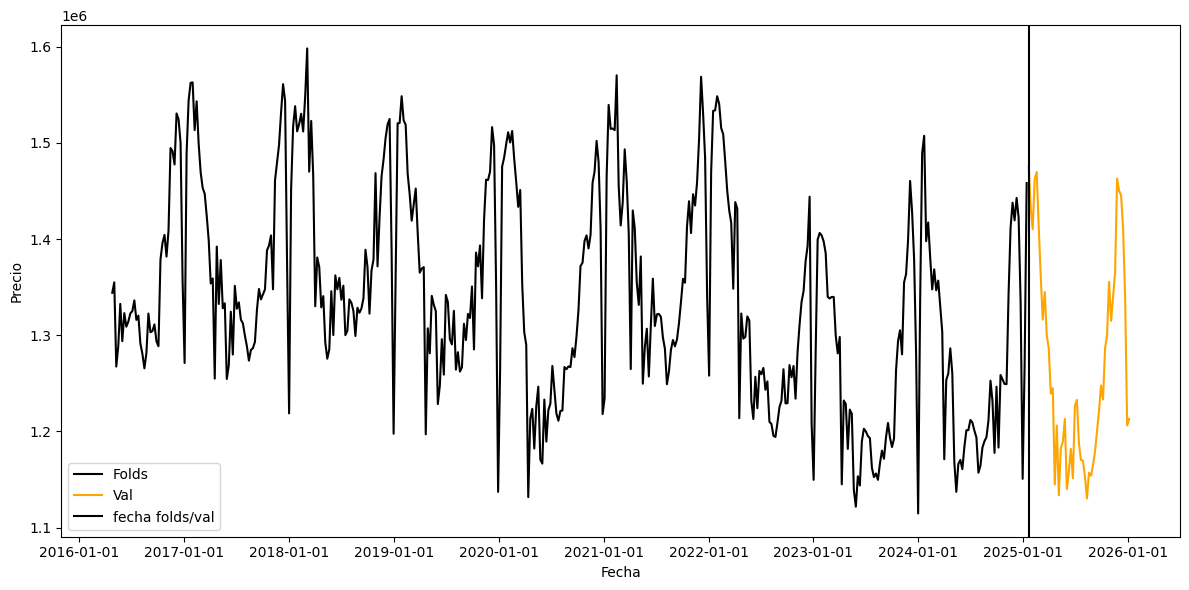

In [10]:
plt.figure(figsize=(12,6))
plt.plot(X_folds.index, y_folds, label="Folds", color="black")
plt.plot(X_val.index, y_val, label="Val", color="orange")
plt.axvline(X_val.index[0], label="fecha folds/val", color="black")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
#plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

### Creación de Folds
Para el conjunto de datos X_Folds se definen una serie de "particiones" que ayudarán a determinar si el modelo encontrado se ajusta de forma consistente en diversas franjas de tiempo, ayudando a evitar inferir correlaciones espurias 

In [11]:
# visualizacion de los folds 
# se muestra de forma visual como funcionan los folds
# si no se define el tamaño de test, en la primera iteracion se toma igual cantidad de datos para train que para test
# por eso se toman los folds de prueba como de la longitud de datos de validación
size_test = int(len(X_val))
gap = 0 # distancia (cantidad de observaciones) que se deja entre train y test
n_splits = 5
tscv = TimeSeriesSplit(
    n_splits=n_splits,
    test_size=size_test, 
    #gap=gap
)

folds, indexes, types = [], [], []

for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_folds)):
    folds.extend([fold_idx] * len(train_idx)) 
    indexes.extend(train_idx)
    types.extend(['Train'] * len(train_idx))

    folds.extend([fold_idx] * len(test_idx))
    indexes.extend(test_idx)
    types.extend(['Test'] * len(test_idx))

# figura con plotly
fig = go.Figure()

# data train
fig.add_trace(go.Scatter(
    x=indexes, y=folds,
    mode='markers',
    marker=dict(color=['blue' if t == 'Train' else 'orange' for t in types], size=6),
    text=types,
    hovertemplate='Index: %{x}<br> Fold: %{y}<br> Tipo: %{text}<extra></extra>'
))

fig.update_layout(
    title='Folds',
    xaxis_title='Indices serie',
    yaxis_title='Fold',
    yaxis=dict(autorange='reversed'),
    legend_title='Tipo de conjunto',
    template='plotly_white',
    height=400
)
fig.show()

Función para crear el modelo

In [12]:
# función de creación del modelo 
def build_xgboost_regressor(**params):
    # puedes establecer valores por defecto si faltan
    params.setdefault("objective", "reg:squarederror")
    params.setdefault("tree_method", "exact")
    params.setdefault("random_state", 42)

    model = xgboost.XGBRegressor(**params)
    return model


# Función de optimización

Mediante el uso de Optuna (una librería basada en técnicas de optimización bayesiana secuencial) se define una función de optimización que utiliza validación cruzada temporal para minimizar una métrica de error (en este caso, el MAPE*).

La función está dada de la siguiente forma: primero, se definen los hiperparámetros de la rnn: número de rezagos, unidades recurrentes, tasa de aprendizaje, tamaño de lote y número de épocas.   Para cada uno de estos parámetros se especifican rangos o conjuntos discretos de valores que Optuna explorará con el fin de encontrar la combinación que minimice el error promedio.

Posteriormente, se inicializan listas que almacenarán las métricas de evaluación obtenidas en cada fold (MAPE, MAE y RMSE).  
Durante cada iteración del proceso de validación cruzada, se realiza lo siguiente:
0. se definen los conjuntos train/test de acuerdo con ese fold
1. Se instancia un nuevo modelo RNN con el conjunto de hiperparámetros seleccionados para el trial actual.  
2. Se entrena el modelo sobre el conjunto de entrenamiento definido para ese fold.  
3. Se evalúa el modelo sobre el conjunto de prueba correspondiente, calculando las métricas de error.  

Este proceso se repite para los *k* folds (en este caso, 5), produciendo un conjunto de errores por fold:

- Fold₁ → MAPE₁  
- Fold₂ → MAPE₂  
- Fold₃ → MAPE₃  
- Fold₄ → MAPE₄  
- Fold₅ → MAPE₅  

Así se obtiene el MAPE promedio de los cinco folds:$$ \text{MAPE}_{prom} = \frac{1}{5} \sum_{i=1}^{5} \text{MAPE}_i $$

Este valor se devuelve como resultado de la función objetivo, y representa el desempeño promedio del modelo bajo ese conjunto de hiperparámetros. Optuna repite este proceso en múltiples trials, cada uno con una combinación diferente de hiperparámetros, y selecciona el conjunto que minimiza el MAPE promedio obtenido.


In [13]:
print(len(X_folds))
print(len(X_val))

456
51


In [14]:
def objective(trial):
    # Parámetros del modelo
    #lag = trial.suggest_categorical("lag", [1, 2, 7, 15, 30, 90])
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "min_child_weight": trial.suggest_float("min_child_weight", 5.0, 15.0),
        "gamma": trial.suggest_float("gamma", 1e-3, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 5.0),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "objective": "reg:squarederror",
        "tree_method": "exact",
        "random_state": 42
    }

    # Datos supervisados
    


    # Métricas a recolectar
    mapes, maes, rmses, smapes, variables = [], [], [], [], []



    # Validación cruzada temporal
    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_folds)):
        variables = {}

        # División train/test (sin escalado)
        X_train, X_test = X_folds.iloc[train_idx], X_folds.iloc[test_idx]
        y_train = y_folds.iloc[train_idx].values
        y_test  = y_folds.iloc[test_idx].values

        
        # Entrenamiento, prediccion y metricas 
        model = build_xgboost_regressor(**params)
        model.fit(X_train, y_train)


        y_pred = model.predict(X_test)

        mae  = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        smape_calc = MeanAbsolutePercentageError(symmetric=True) 
        smape = smape_calc(y_test, y_pred)

        mapes.append(mape)
        maes.append(mae)
        rmses.append(rmse)
        smapes.append(smape)

        for i  in range(len(X_train.columns)):
            variables[X.columns[i]] = model.feature_importances_[i]



        # Registro 
        trial.set_user_attr(f"fold_{fold_idx + 1}", {
            "mae": mae,
            "mape": mape,
            "rmse": rmse, 
            "smape": smape,
            f"importancia_variables_fold_{fold_idx + 1}": variables
        })
        trial.report(np.mean(mapes), step=fold_idx)

   
    # Función objetivo
    mean_mape = np.mean(mapes)
    median_mape = np.median(mapes)
    mean_smape = np.mean(smapes)
    mean_rmse = np.mean(rmses)
    mean_mae = np.mean(maes)

    trial.set_user_attr("mape_mean", mean_mape)
    trial.set_user_attr("mape_median", median_mape)
    trial.set_user_attr("mae_mean", mean_mae)
    trial.set_user_attr("rmse_mean", mean_rmse)
    trial.set_user_attr("smape_mean", mean_smape)
    
    std_mape  = np.std(mapes)
    #return float(mean_mape) #+ 0.25 * std_mape)
    return float(median_mape) #+ 0.25 * std_mape)

print("Optimización con Optuna en curso...")
study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50)
best_params = study.best_params
print("Mejores parámetros encontrados:\n", best_params)

[I 2026-04-07 19:04:43,126] A new study created in memory with name: no-name-f3dafb2c-0a47-4f49-8e0a-5cfa6bc672ea


Optimización con Optuna en curso...


[I 2026-04-07 19:04:46,004] Trial 0 finished with value: 0.042984606362241155 and parameters: {'n_estimators': 350, 'max_depth': 8, 'learning_rate': 0.07587945476302646, 'min_child_weight': 10.986584841970366, 'gamma': 0.1568626218019941, 'reg_lambda': 0.864373149647393, 'reg_alpha': 0.38460969962417735, 'subsample': 0.9464704583099741, 'colsample_bytree': 0.8404460046972835}. Best is trial 0 with value: 0.042984606362241155.
[I 2026-04-07 19:04:47,312] Trial 1 finished with value: 0.03874658206126597 and parameters: {'n_estimators': 483, 'max_depth': 3, 'learning_rate': 0.0972918866945795, 'min_child_weight': 13.324426408004218, 'gamma': 0.21312677156759788, 'reg_lambda': 0.990942339314793, 'reg_alpha': 0.9986820982818257, 'subsample': 0.7216968971838151, 'colsample_bytree': 0.8099025726528951}. Best is trial 1 with value: 0.03874658206126597.
[I 2026-04-07 19:04:48,544] Trial 2 finished with value: 0.03800674464471251 and parameters: {'n_estimators': 373, 'max_depth': 4, 'learning_ra

Mejores parámetros encontrados:
 {'n_estimators': 239, 'max_depth': 6, 'learning_rate': 0.03198134598969804, 'min_child_weight': 5.463726912530138, 'gamma': 0.6015479170703093, 'reg_lambda': 2.1683893891057258, 'reg_alpha': 3.0153380468199855, 'subsample': 0.7983833232263956, 'colsample_bytree': 0.6183441323093343}


Se extraen los resultados del mejor trial

In [15]:
# Extraer resultados del mejor trial
best_trial = study.best_trial
print("Mejor trial:", best_trial.number)
print("MAPE promedio:", best_trial.value)
print("Atributos guardados:")
print(best_trial.user_attrs)


Mejor trial: 41
MAPE promedio: 0.03379137099840583
Atributos guardados:
{'fold_1': {'mae': 57571.106792717095, 'mape': 0.045896907771947264, 'rmse': 71963.85491280613, 'smape': 0.04441328109898557, 'importancia_variables_fold_1': {'year': 0.015991217, 'month': 0.066811025, 'quarter': 0.056872316, 'value_lag_1': 0.23286995, 'value_lag_2': 0.017436538, 'value_lag_3': 0.012179229, 'value_lag_4': 0.016275797, 'value_lag_8': 0.019726317, 'value_lag_12': 0.018226445, 'value_lag_52': 0.32540125, 'value_ma_2': 0.067036696, 'value_ma_3': 0.031215405, 'value_ma_4': 0.06748926, 'value_ma_8': 0.017691094, 'value_ma_12': 0.022565536, 'value_ma_16': 0.012211956}}, 'fold_2': {'mae': 36090.55112044817, 'mape': 0.026078740718913414, 'rmse': 47646.09893017731, 'smape': 0.02656171424202397, 'importancia_variables_fold_2': {'year': 0.03085792, 'month': 0.031557776, 'quarter': 0.100010686, 'value_lag_1': 0.20436546, 'value_lag_2': 0.021157824, 'value_lag_3': 0.016268924, 'value_lag_4': 0.012913681, 'value_

Se extraen los datos de asignación de puntaje de variables para elxaminar la asignación de importancia a nivel general y por fold

In [16]:
# df de comportamiento de variables
rows = []

for i in range(n_splits):
    fold_key = f"fold_{i+1}"
    imp_key = f"importancia_variables_fold_{i+1}"

    for var, val in best_trial.user_attrs[fold_key][imp_key].items():
        rows.append({
            "variable": var,
            "fold": i + 1,
            "importancia": val
        })

df_importancias = pd.DataFrame(rows)
df_importancias

,variable,fold,importancia
0,year,1,0.015991
1,month,1,0.066811
2,quarter,1,0.056872
3,value_lag_1,1,0.232870
4,value_lag_2,1,0.017437
...,...,...,...
75,value_ma_3,5,0.073689
76,value_ma_4,5,0.075981
77,value_ma_8,5,0.031969
78,value_ma_12,5,0.020407


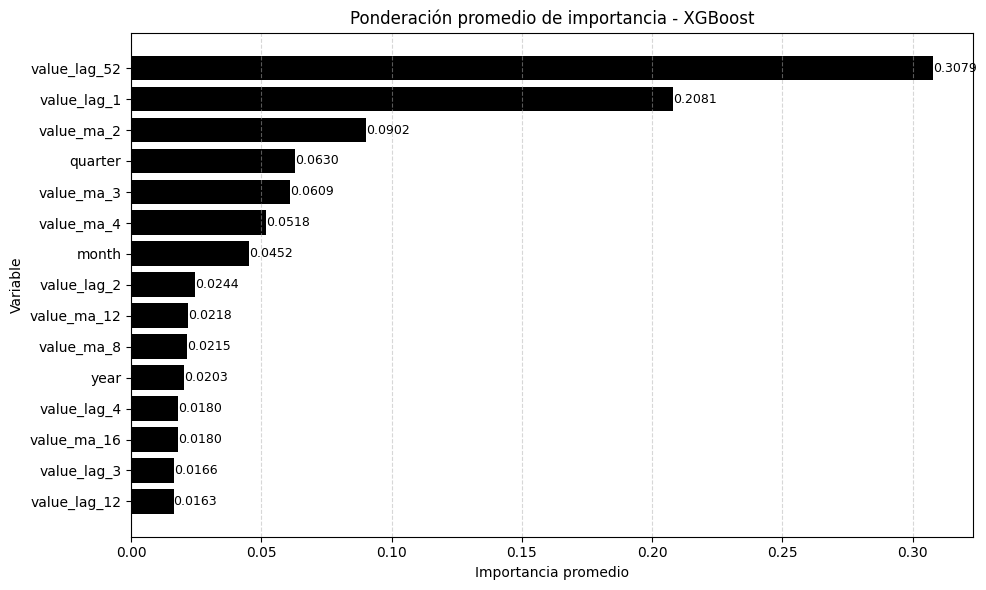

In [17]:
# Estadísticas promedio por variable
df_hist_avg_vars = (
    df_importancias
        .groupby("variable", as_index=False)["importancia"]
        .mean()
        .sort_values("importancia", ascending=False)
)

# filtrar importancia estrictamente positiva
df_hist_avg_vars = df_hist_avg_vars[df_hist_avg_vars["importancia"] > 0]

# opcional: tomar top 15 para que el gráfico sea legible
top_k = 15
df_plot = df_hist_avg_vars.head(top_k)

plt.figure(figsize=(10, 6))
bars = plt.barh(df_plot["variable"], df_plot["importancia"], color="black")

# agregar valores numéricos al lado de cada barra
for i, v in enumerate(df_plot["importancia"]):
    plt.text(v, i, f"{v:.4f}", va="center", fontsize=9)

plt.gca().invert_yaxis()
plt.title("Ponderación promedio de importancia - XGBoost")
plt.xlabel("Importancia promedio")
plt.ylabel("Variable")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Asignaión de puntajes por fold

In [18]:
# matriz de importancias por fold
df_stats_by_folds = []

for i in range(n_splits):

    df_fold = df_importancias[
        (df_importancias["fold"] == i+1) &
        (df_importancias["importancia"] > 0.00)
    ]

    df_fold_matrix = (
        df_fold
        .pivot_table(
            index="fold",
            columns="variable",
            values="importancia",
            aggfunc="sum"
        )
        .reset_index()
    )

    df_stats_by_folds.append(df_fold_matrix)

# unir todos los folds
df_stats_by_folds = pd.concat(df_stats_by_folds, ignore_index=True)
df_stats_by_folds

variable,fold,month,quarter,value_lag_1,value_lag_12,value_lag_2,value_lag_3,value_lag_4,value_lag_52,value_lag_8,value_ma_12,value_ma_16,value_ma_2,value_ma_3,value_ma_4,value_ma_8,year
0,1,0.066811,0.056872,0.232870,0.018226,0.017437,0.012179,0.016276,0.325401,0.019726,0.022566,0.012212,0.067037,0.031215,0.067489,0.017691,0.015991
1,2,0.031558,0.100011,0.204365,0.013288,0.021158,0.016269,0.012914,0.332290,0.015994,0.019767,0.014159,0.063549,0.064693,0.046080,0.013049,0.030858
2,3,0.064060,0.068745,0.161124,0.010949,0.020803,0.021246,0.017519,0.311665,0.013728,0.021232,0.014583,0.129481,0.082510,0.031730,0.016096,0.014529
3,4,0.031325,0.048487,0.176231,0.022100,0.023568,0.014640,0.022633,0.343821,0.014034,0.025063,0.031503,0.108964,0.052345,0.037882,0.028468,0.018935
4,5,0.032041,0.040807,0.266075,0.016757,0.039082,0.018495,0.020703,0.226093,0.017679,0.020407,0.017481,0.081800,0.073689,0.075981,0.031969,0.020942


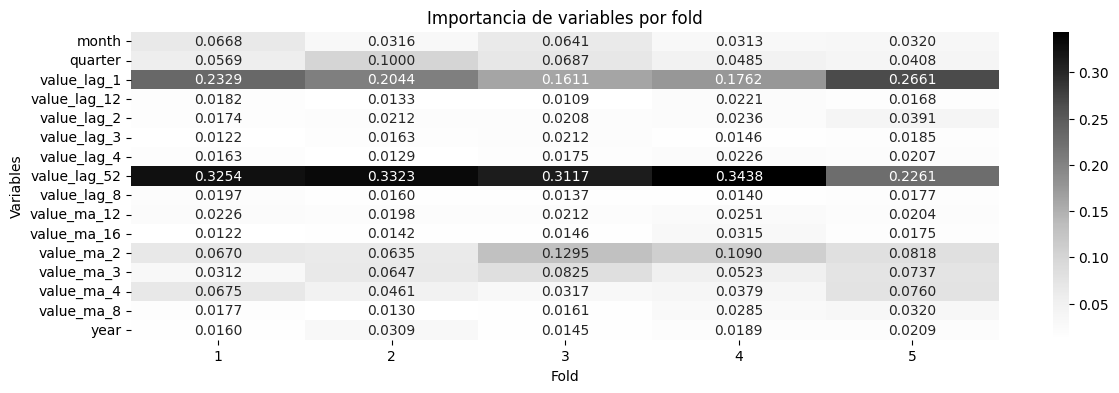

In [19]:

df_plot = df_stats_by_folds.set_index("fold")

plt.figure(figsize=(14,4))
sns.heatmap(df_plot.T, cmap="Greys", annot=True, fmt=".4f")
plt.title("Importancia de variables por fold")
plt.xlabel("Fold")
plt.ylabel("Variables")
plt.show()

In [20]:
df_stats_by_folds["fold"]

0    1
1    2
2    3
3    4
4    5
Name: fold, dtype: int64

In [21]:
df_stats_by_folds_1 = df_stats_by_folds.reset_index(drop=True)
df_stats_by_folds_1

variable,fold,month,quarter,value_lag_1,value_lag_12,value_lag_2,value_lag_3,value_lag_4,value_lag_52,value_lag_8,value_ma_12,value_ma_16,value_ma_2,value_ma_3,value_ma_4,value_ma_8,year
0,1,0.066811,0.056872,0.232870,0.018226,0.017437,0.012179,0.016276,0.325401,0.019726,0.022566,0.012212,0.067037,0.031215,0.067489,0.017691,0.015991
1,2,0.031558,0.100011,0.204365,0.013288,0.021158,0.016269,0.012914,0.332290,0.015994,0.019767,0.014159,0.063549,0.064693,0.046080,0.013049,0.030858
2,3,0.064060,0.068745,0.161124,0.010949,0.020803,0.021246,0.017519,0.311665,0.013728,0.021232,0.014583,0.129481,0.082510,0.031730,0.016096,0.014529
3,4,0.031325,0.048487,0.176231,0.022100,0.023568,0.014640,0.022633,0.343821,0.014034,0.025063,0.031503,0.108964,0.052345,0.037882,0.028468,0.018935
4,5,0.032041,0.040807,0.266075,0.016757,0.039082,0.018495,0.020703,0.226093,0.017679,0.020407,0.017481,0.081800,0.073689,0.075981,0.031969,0.020942


In [22]:
df_long = df_stats_by_folds.melt(
    id_vars=["fold"], 
    var_name="variable", 
    value_name="importancia"
).sort_values(by="importancia", ascending=False)

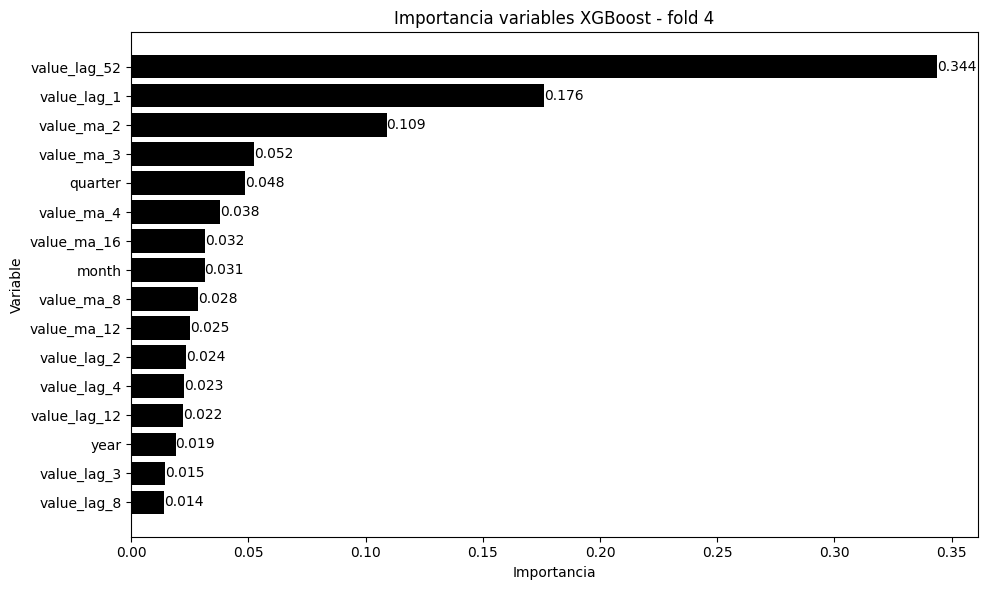

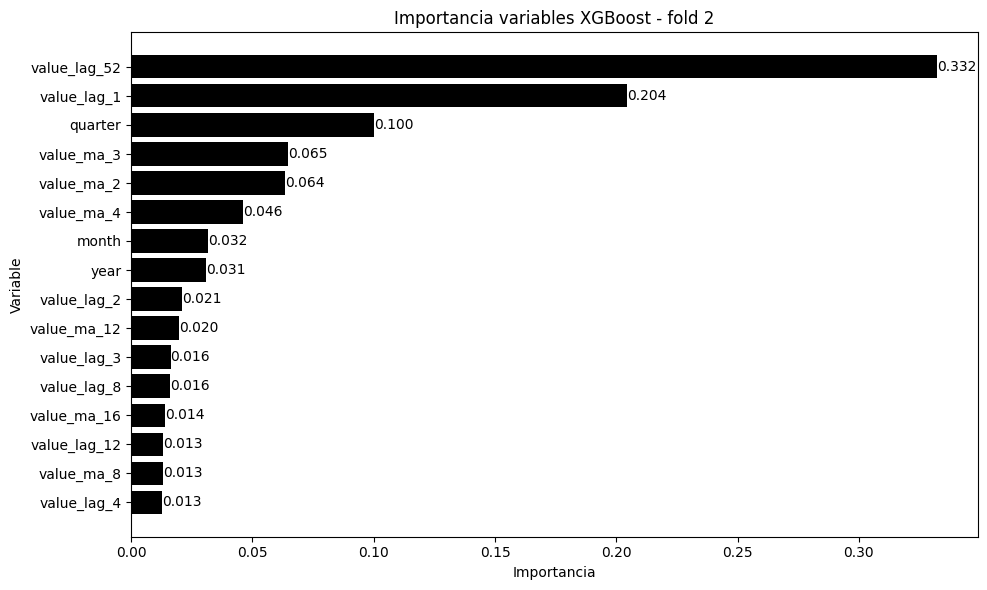

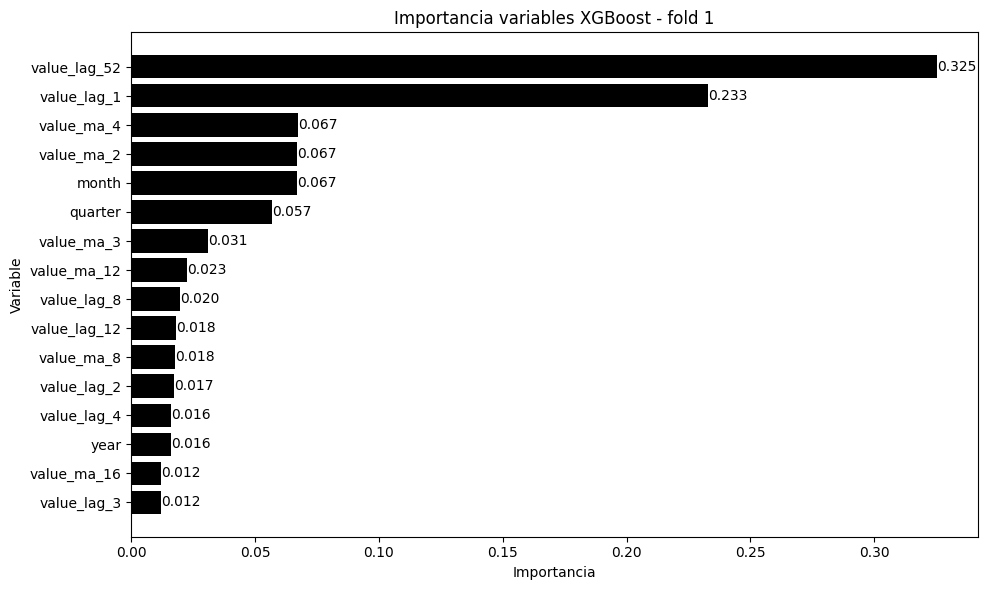

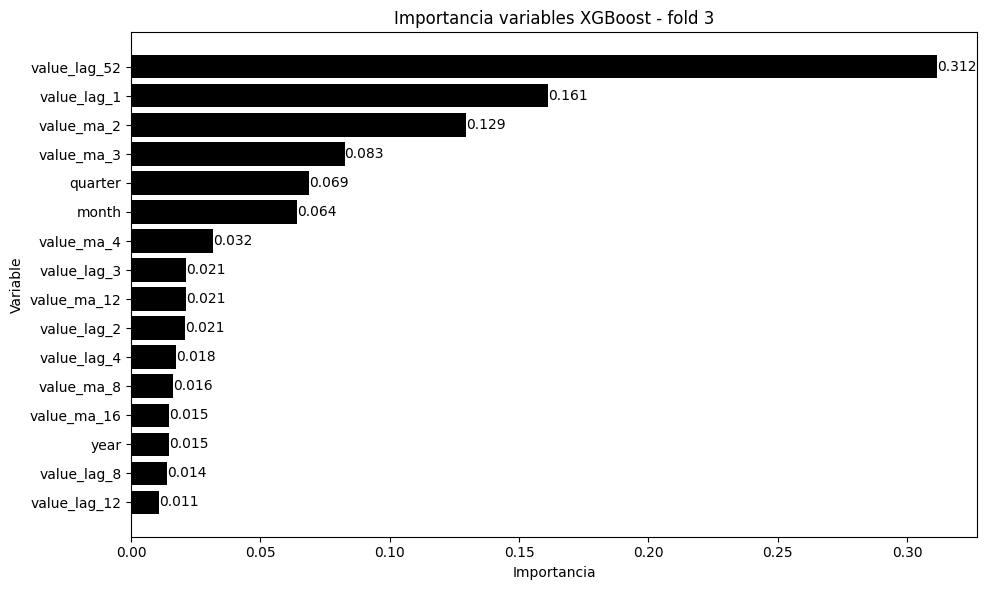

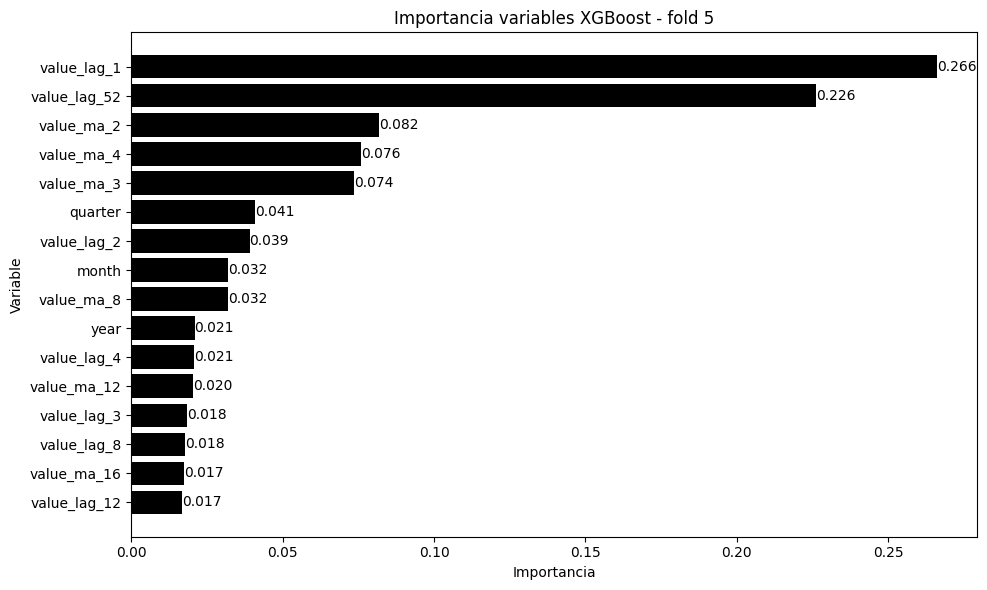

In [23]:
for fold in df_long["fold"].unique():
    df_fold = df_long[df_long["fold"] == fold]
    
    plt.figure(figsize=(10,6))
    bars = plt.barh(df_fold["variable"], df_fold["importancia"], color="black")
    plt.gca().invert_yaxis()
    
    plt.title(f"Importancia variables XGBoost - fold {fold}")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")

    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, f"{width:.3f}", va="center")

    plt.tight_layout()
    plt.show()

se obtiene todo el listado de los trials ejecutados y se crea un df que muestra los errores por fold y por trial

In [24]:

# info de los trials 
# se extraen los trials
trials = study.get_trials()
# creación del df a nivel de registro
# el esquema del df se infiere a partir de las claves almacenadas en cada registro (las claves no varían, dado como se guardaron)
rows = [] # se usará para guardar la info a nivel de registro
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs # los valores de las métricas se definen en la función como 
    # un atributo de usuario, definido como un diccionario
    # se recorren ahora las claves y los valores de cada diccionario
    for key, value in attrs.items():
        if key.startswith("fold_") and isinstance(value, dict): 
            # se examina si cada clave del diccionario empieza con fold_. Recordar que en la función
            # se guardó un diccionario con el nombre fold_i_metrics, que guarda la info de cada fold y cada trial.
            # Se mira entonces si la clave es de esa forma y si el valor de esa clave es un diccionario
            rows.append({
                "trial": trial_number,
                "fold": int(key.replace("fold_", "")),   # extraer número
                "mape": value["mape"],
                "mae": value["mae"],
                "rmse": value["rmse"],
                "smape": value["smape"]
            })

df_metrics = pd.DataFrame(rows)
df_metrics.head()


,trial,fold,mape,mae,rmse,smape
0,0,1,0.044134,55514.903361,70902.180012,0.042821
1,0,2,0.028915,40075.284314,52559.359813,0.029504
2,0,3,0.042985,54858.844888,77740.327235,0.041316
3,0,4,0.046979,58955.459034,73919.519535,0.046212
4,0,5,0.034077,43467.237045,52702.445701,0.034370


In [25]:
# descripción general del df de métricas
df_stats = df_metrics.describe()
df_stats[["mape", "mae", "rmse", "smape"]]

,mape,mae,rmse,smape
count,250.000000,250.000000,250.000000,250.000000
mean,0.037647,48223.790842,62658.391154,0.037072
std,0.007320,8200.152712,10484.805191,0.006677
min,0.024787,34664.852241,44136.628906,0.025164
25%,0.030630,40142.435399,50780.963520,0.030901
50%,0.037217,47205.670518,67328.572408,0.035932
75%,0.044843,56366.081145,71908.887497,0.043607
max,0.052373,64486.490896,79820.072564,0.050896


Se examina el comportamiento de los errores por fold y por trial, mediante los histogramas relacionados

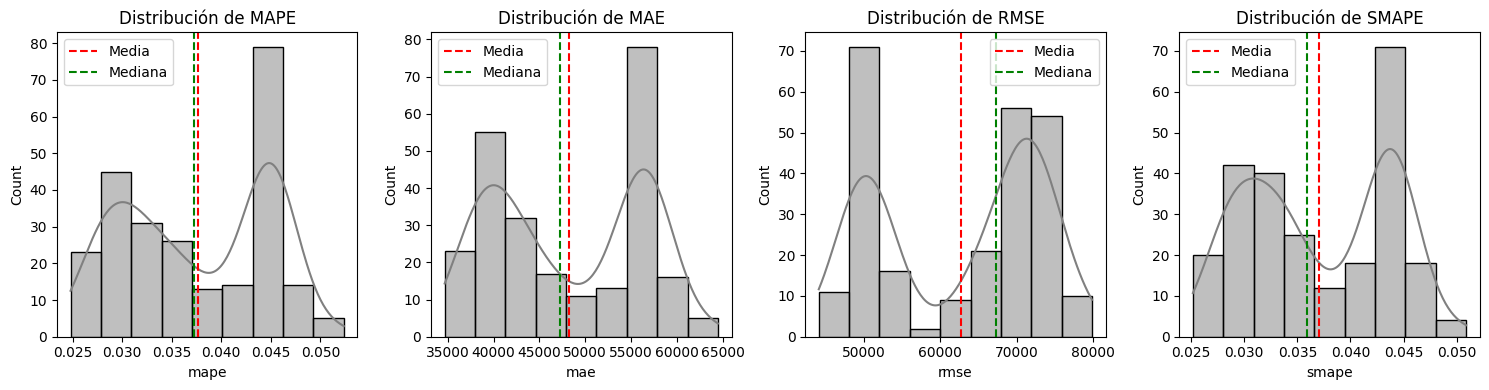

In [26]:
# histogramas de los errores por trial y por fold
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, metric in zip(axes, ["mape", "mae", "rmse", "smape"]):
    sns.histplot(df_metrics[metric], kde=True, ax=ax, color="gray")
    ax.set_title(f"Distribución de {metric.upper()}")
    ax.axvline(df_metrics[metric].mean(), color='red', linestyle='--', label='Media')
    ax.axvline(df_metrics[metric].median(), color='green', linestyle='--', label='Mediana')
    """ if metric == 'mape':
        medians_df['mape'] = df_metrics[metric].median() """
    ax.legend()

plt.tight_layout()
plt.show()


Se ordena por métrica 

In [27]:
# Ordenar por cada métrica para tomar los mejores conjuntos de parametros
df_mape_sorted = df_metrics.sort_values("mape", ascending=True).reset_index(drop=True)
df_mae_sorted = df_metrics.sort_values("mae", ascending=True).reset_index(drop=True)
df_rmse_sorted = df_metrics.sort_values("rmse", ascending=True).reset_index(drop=True)
df_smape_sorted = df_metrics.sort_values("smape", ascending=True).reset_index(drop=True)

print("Mejores Folds por MAPE:")
print(df_mape_sorted.tail())

print("\Mejores Folds por MAE:")
print(df_mae_sorted.tail())

print("\Mejores Folds por RMSE:")
print(df_rmse_sorted.tail())

print("\Mejores Folds por sMAPE:")
print(df_smape_sorted.tail())

Mejores Folds por MAPE:
     trial  fold      mape           mae          rmse     smape
245     26     4  0.049484  61522.653361  75771.696888  0.048324
246     49     1  0.049718  62473.114496  76983.961407  0.048029
247     36     4  0.050134  63252.891106  78817.135240  0.049295
248     28     4  0.051954  64417.035714  78026.683568  0.050680
249     49     4  0.052373  64486.490896  77436.876952  0.050896
\Mejores Folds por MAE:
     trial  fold      mape           mae          rmse     smape
245     26     4  0.049484  61522.653361  75771.696888  0.048324
246     49     1  0.049718  62473.114496  76983.961407  0.048029
247     36     4  0.050134  63252.891106  78817.135240  0.049295
248     28     4  0.051954  64417.035714  78026.683568  0.050680
249     49     4  0.052373  64486.490896  77436.876952  0.050896
\Mejores Folds por RMSE:
     trial  fold      mape           mae          rmse     smape
245     28     4  0.051954  64417.035714  78026.683568  0.050680
246      5     3 

Se crea df que obtiene los hiperparametros por fold junto con las metricas asociadas, se toman los 3 que dejan menor mape promedio para comparar y luego se toma uno solo

In [28]:
df_trials = {   
    "trial" :[],
    "n_estimators": [],
    "max_depth": [],
    "learning_rate": [],
    "min_child_weight": [] ,
    "gamma": [],
    "reg_lambda" : [],
    "reg_alpha" : [],
    "subsample" : [],
    "colsample_bytree": [],
    "mape_mean": [],
    "mae_mean": [],
    "rmse_mean": [],
    "smape_mean": []
}

for trial in trials:
    for key in df_trials.keys():

        if key == "trial":
            df_trials[key].append(trial.number)

        elif key in ["mape_mean", "mae_mean", "rmse_mean", "smape_mean"]:
            df_trials[key].append(round(trial.user_attrs[key],4))

        else: 
            df_trials[key].append(round(trial.params[key],5))
   
df_params_models = pd.DataFrame(df_trials)
df_params_models = df_params_models.sort_values("mape_mean") # se ordenan conjuntos de hiperparametros que dejan menor mape promedio y se toma
# el menor
df_params_models.head(3)

,trial,n_estimators,max_depth,learning_rate,min_child_weight,gamma,reg_lambda,reg_alpha,subsample,colsample_bytree,mape_mean,mae_mean,rmse_mean,smape_mean
41,41,239,6,0.03198,5.46373,0.60155,2.16839,3.01534,0.79838,0.61834,0.0363,46374.8691,60321.6859,0.0357
25,25,253,7,0.02193,5.93459,0.88000,0.10699,4.24852,0.75779,0.67852,0.0363,46466.1340,61379.2794,0.0357
46,46,305,6,0.01592,7.35351,0.70418,2.64177,4.42778,0.72930,0.62542,0.0364,46622.0861,60843.0425,0.0358


In [29]:
# se exporta el df con los mejores modelos 
df_params_models.head(3).to_csv("../../../data/best_train_models/best_models_xgboost.csv")

In [30]:
# organización de hiperparametros
# Corrección
params_xgb = {
    k: v 
    for k, v in study.best_params.items() 
    if k != 'lag'
}
study.best_params

# La variable params_xgb contendrá solo los hiperparámetros de XGBoost
# (n_estimators, max_depth, learning_rate, etc.),

{'n_estimators': 239,
 'max_depth': 6,
 'learning_rate': 0.03198134598969804,
 'min_child_weight': 5.463726912530138,
 'gamma': 0.6015479170703093,
 'reg_lambda': 2.1683893891057258,
 'reg_alpha': 3.0153380468199855,
 'subsample': 0.7983833232263956,
 'colsample_bytree': 0.6183441323093343}

In [31]:
len(X_val)

51

In [32]:
# se fija el modelo con los mejores hiperparametros con los datos finales, se hacen la prediccione y se examinan los errores oos
best_model = build_xgboost_regressor(**params_xgb)
best_model.fit(X_folds, y_folds)
y_pred = best_model.predict(X_val)

# metricas de error 

mape_val = mean_absolute_percentage_error(y_pred, y_val)
mae_val = mean_absolute_error(y_pred, y_val)
rmse_val = np.sqrt(mean_squared_error(y_pred, y_val))
smape_calc_val = MeanAbsolutePercentageError(symmetric=True) 
smape_val = smape_calc_val(y_pred, y_val)

print(f"mape validación: {mape_val*100:.4f}%")
print(f"mape validación: {mae_val}")
print(f"rmse validación: {rmse_val}")
print(f"smape validación: {smape_val*100:.4f}")

mape validación: 2.3287%
mape validación: 29440.5
rmse validación: 38090.45906785582
smape validación: 2.3241


In [33]:
y_folds

,value
0,1.344112e+06
1,1.354987e+06
2,1.267394e+06
3,1.288666e+06
4,1.332559e+06
...,...
451,1.422410e+06
452,1.333686e+06
453,1.150707e+06
454,1.270610e+06


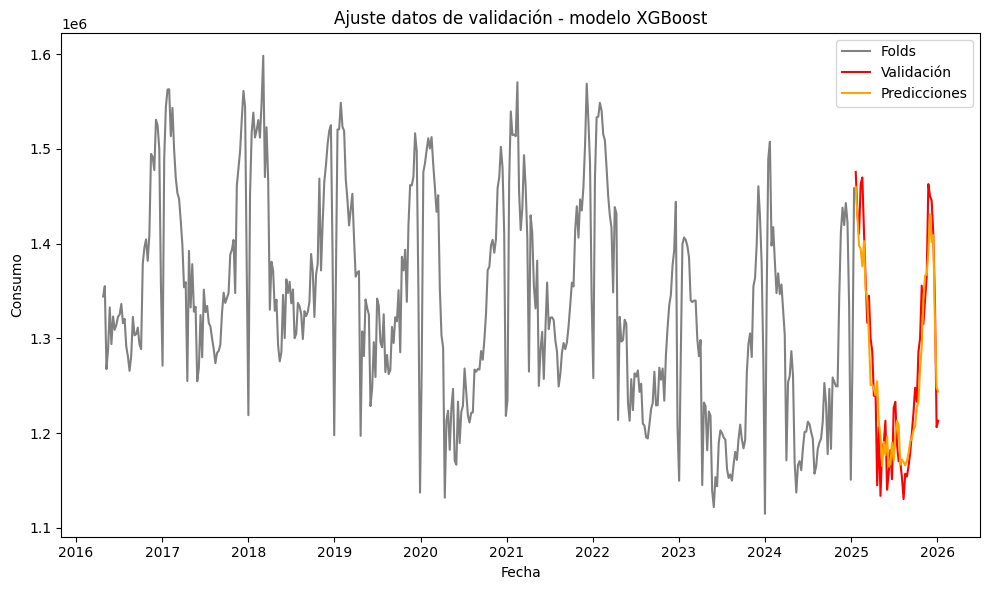

In [34]:
# ajute visual 
plt.figure(figsize=(10,6))
plt.plot(X_folds.index, y_folds , label="Folds", color="gray")
plt.plot(X_val.index, y_val, label="Validación", color="red")
plt.plot(X_val.index[-len(y_pred):], y_pred, label="Predicciones", color="orange")
plt.title("Ajuste datos de validación - modelo XGBoost")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
#plt.grid(True)
plt.legend()
plt.tight_layout()

Se exportan las predicciones en json para poder calcular luego la predicción conjunta

In [35]:
df_data_close[folds_data_size:]["Start date"]

456   2025-01-20
457   2025-01-27
458   2025-02-03
459   2025-02-10
460   2025-02-17
461   2025-02-24
462   2025-03-03
463   2025-03-10
464   2025-03-17
465   2025-03-24
466   2025-03-31
467   2025-04-07
468   2025-04-14
469   2025-04-21
470   2025-04-28
471   2025-05-05
472   2025-05-12
473   2025-05-19
474   2025-05-26
475   2025-06-02
476   2025-06-09
477   2025-06-16
478   2025-06-23
479   2025-06-30
480   2025-07-07
481   2025-07-14
482   2025-07-21
483   2025-07-28
484   2025-08-04
485   2025-08-11
486   2025-08-18
487   2025-08-25
488   2025-09-01
489   2025-09-08
490   2025-09-15
491   2025-09-22
492   2025-09-29
493   2025-10-06
494   2025-10-13
495   2025-10-20
496   2025-10-27
497   2025-11-03
498   2025-11-10
499   2025-11-17
500   2025-11-24
501   2025-12-01
502   2025-12-08
503   2025-12-15
504   2025-12-22
505   2025-12-29
506   2026-01-05
Name: Start date, dtype: datetime64[ns]

In [36]:
arr_preds = []
for index, value in enumerate(df_data_close[folds_data_size:]["Start date"]):
    dict_pred = {
        "Date": value.strftime("%Y-%m-%d"), # convierte a la fecha a string para poder exportar a json
        "pred" : float(y_pred[index])
    }
    arr_preds.append(dict_pred)
arr_preds

[{'Date': '2025-01-20', 'pred': 1459712.5},
 {'Date': '2025-01-27', 'pred': 1429747.625},
 {'Date': '2025-02-03', 'pred': 1397622.125},
 {'Date': '2025-02-10', 'pred': 1394670.5},
 {'Date': '2025-02-17', 'pred': 1376000.125},
 {'Date': '2025-02-24', 'pred': 1402528.375},
 {'Date': '2025-03-03', 'pred': 1351091.875},
 {'Date': '2025-03-10', 'pred': 1340302.0},
 {'Date': '2025-03-17', 'pred': 1301317.75},
 {'Date': '2025-03-24', 'pred': 1250750.875},
 {'Date': '2025-03-31', 'pred': 1250958.875},
 {'Date': '2025-04-07', 'pred': 1246736.625},
 {'Date': '2025-04-14', 'pred': 1239858.75},
 {'Date': '2025-04-21', 'pred': 1254704.25},
 {'Date': '2025-04-28', 'pred': 1211811.25},
 {'Date': '2025-05-05', 'pred': 1196750.75},
 {'Date': '2025-05-12', 'pred': 1165146.125},
 {'Date': '2025-05-19', 'pred': 1190677.875},
 {'Date': '2025-05-26', 'pred': 1176309.0},
 {'Date': '2025-06-02', 'pred': 1196504.0},
 {'Date': '2025-06-09', 'pred': 1164511.375},
 {'Date': '2025-06-16', 'pred': 1166960.0},
 {'Da

In [37]:
# Cálculo de métricas agregadas
dict_to_export = {
    "mape_val": float(mape_val),
    "mae_val": float(mae_val),
    "smape_val": float(smape_val),
    "rmse_val": float(rmse_val),
    "predictions": arr_preds
}
#$with open ("../../../data/preds_energy_models/xgboost_preds.json", "w") as json_file:
#    json.dump(dict_to_export, json_file, indent=4)